In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

In [2]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
raw_path = "초반dataset.csv"
feature_path = "파생변수.csv"

def read_csv_auto(path):
    for enc in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError("CSV 인코딩을 확인해주세요.")

raw_df = read_csv_auto(raw_path)
df = read_csv_auto(feature_path)

print("원본 데이터 크기:", raw_df.shape)
print("파생변수 데이터 크기:", df.shape)

print("\n파생변수 컬럼:")
print(df.columns.tolist())

원본 데이터 크기: (1033, 35)
파생변수 데이터 크기: (512, 30)

파생변수 컬럼:
['Player', 'season', 'Date_fixed', 'Team', 'Opponent', 'home', 'Status', 'starter_flag', 'Pos', 'W/L', 'current_MIN', 'current_FP', 'current_FP_per_MIN', 'target_FP_per_MIN_drop_5', 'target_FP_per_MIN_drop_rate', 'recent3_weighted_FP_per_MIN', 'recent3_TS_avg', 'recent3_TOV_avg', 'recent3_PTS_avg', 'recent3_REB_avg', 'recent3_AST_avg', 'recent3_STL_avg', 'recent3_BLK_avg', 'recent3_MIN_avg', 'recent5_MIN_sum', 'recent5_high_MIN_count', 'rest_days_fixed', 'back_to_back', 'recent3_USG_Proxy_per_MIN_avg', 'recent5_USG_Proxy_sum']


In [4]:
print("데이터 크기:", df.shape)

print("\n데이터 타입:")
print(df.dtypes)

print("\n결측치 개수:")
print(df.isnull().sum().sort_values(ascending=False))

print("\n앞부분 확인:")
display(df.head())

데이터 크기: (512, 30)

데이터 타입:
Player                            object
season                            object
Date_fixed                        object
Team                              object
Opponent                          object
home                               int64
Status                            object
starter_flag                       int64
Pos                               object
W/L                               object
current_MIN                      float64
current_FP                       float64
current_FP_per_MIN               float64
target_FP_per_MIN_drop_5           int64
target_FP_per_MIN_drop_rate      float64
recent3_weighted_FP_per_MIN      float64
recent3_TS_avg                   float64
recent3_TOV_avg                  float64
recent3_PTS_avg                  float64
recent3_REB_avg                  float64
recent3_AST_avg                  float64
recent3_STL_avg                  float64
recent3_BLK_avg                  float64
recent3_MIN_avg               

,Player,season,Date_fixed,Team,Opponent,home,Status,starter_flag,Pos,W/L,...,recent3_AST_avg,recent3_STL_avg,recent3_BLK_avg,recent3_MIN_avg,recent5_MIN_sum,recent5_high_MIN_count,rest_days_fixed,back_to_back,recent3_USG_Proxy_per_MIN_avg,recent5_USG_Proxy_sum
0,Assem Marei,24-25,2024-12-07,Changwon LG Sakers,Wonju Dongbu Promy,1,Starter,1,C,W,...,4.667,1.000,0.333,27.183,143.60,2,2,0,0.631,88.12
1,Assem Marei,24-25,2024-12-09,Changwon LG Sakers,Korea Gas Corporation,0,Starter,1,C,L,...,5.333,1.000,0.667,28.260,146.38,3,2,0,0.592,80.44
2,Assem Marei,24-25,2024-12-13,Changwon LG Sakers,Anyang KGC,0,Starter,1,C,W,...,6.000,1.000,0.667,27.577,142.48,2,4,0,0.556,80.96
3,Assem Marei,24-25,2024-12-15,Changwon LG Sakers,Jeonju KCC Egis,0,Starter,1,C,W,...,6.333,0.667,0.667,28.570,139.24,2,2,0,0.443,74.08
4,Assem Marei,24-25,2024-12-17,Changwon LG Sakers,Seoul Samsung Thunders,1,Starter,1,C,W,...,5.000,1.667,0.333,26.527,132.63,1,2,0,0.499,68.64


In [5]:
df["Date_fixed"] = pd.to_datetime(df["Date_fixed"])

df = df.sort_values(["Player", "season", "Date_fixed"]).reset_index(drop=True)

display(df.head())

,Player,season,Date_fixed,Team,Opponent,home,Status,starter_flag,Pos,W/L,...,recent3_AST_avg,recent3_STL_avg,recent3_BLK_avg,recent3_MIN_avg,recent5_MIN_sum,recent5_high_MIN_count,rest_days_fixed,back_to_back,recent3_USG_Proxy_per_MIN_avg,recent5_USG_Proxy_sum
0,Assem Marei,24-25,2024-12-07,Changwon LG Sakers,Wonju Dongbu Promy,1,Starter,1,C,W,...,4.667,1.000,0.333,27.183,143.60,2,2,0,0.631,88.12
1,Assem Marei,24-25,2024-12-09,Changwon LG Sakers,Korea Gas Corporation,0,Starter,1,C,L,...,5.333,1.000,0.667,28.260,146.38,3,2,0,0.592,80.44
2,Assem Marei,24-25,2024-12-13,Changwon LG Sakers,Anyang KGC,0,Starter,1,C,W,...,6.000,1.000,0.667,27.577,142.48,2,4,0,0.556,80.96
3,Assem Marei,24-25,2024-12-15,Changwon LG Sakers,Jeonju KCC Egis,0,Starter,1,C,W,...,6.333,0.667,0.667,28.570,139.24,2,2,0,0.443,74.08
4,Assem Marei,24-25,2024-12-17,Changwon LG Sakers,Seoul Samsung Thunders,1,Starter,1,C,W,...,5.000,1.667,0.333,26.527,132.63,1,2,0,0.499,68.64


In [6]:
#Target 분포 확인
target_col = "target_FP_per_MIN_drop_5"

target_counts = df[target_col].value_counts().sort_index()
target_ratio = df[target_col].value_counts(normalize=True).sort_index()

print("Target 개수")
print(target_counts)

print("\nTarget 비율")
print(target_ratio)

Target 개수
target_FP_per_MIN_drop_5
0    267
1    245
Name: count, dtype: int64

Target 비율
target_FP_per_MIN_drop_5
0    0.521484
1    0.478516
Name: proportion, dtype: float64


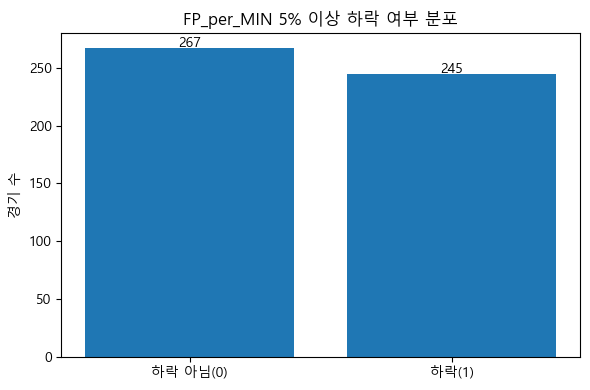

In [7]:
plt.figure(figsize=(6, 4))

labels = ["하락 아님(0)", "하락(1)"]
values = [target_counts.get(0, 0), target_counts.get(1, 0)]

plt.bar(labels, values)
plt.title("FP_per_MIN 5% 이상 하락 여부 분포")
plt.ylabel("경기 수")

for i, v in enumerate(values):
    plt.text(i, v + 1, str(v), ha="center")

plt.tight_layout()
plt.show()

In [10]:
#선수별 하락률 분석
player_summary = (
    df.groupby("Player")
    .agg(
        games=("Player", "count"),
        drop_rate=(target_col, "mean"),
        avg_current_FP_per_MIN=("current_FP_per_MIN", "mean"),
        avg_recent3_FP_per_MIN=("recent3_weighted_FP_per_MIN", "mean"),
        avg_recent5_MIN_sum=("recent5_MIN_sum", "mean"),
        avg_rest_days=("rest_days_fixed", "mean")
    )
    .reset_index()
    .sort_values("drop_rate", ascending=False)
)

display(player_summary)

,Player,games,drop_rate,avg_current_FP_per_MIN,avg_recent3_FP_per_MIN,avg_recent5_MIN_sum,avg_rest_days
3,양홍석,20,0.550000,0.728200,0.787950,112.278000,2.400000
8,허일영,54,0.537037,0.555130,0.582296,83.402963,2.722222
7,최형찬,32,0.531250,0.546406,0.574469,78.621250,2.562500
5,윤원상,21,0.523810,0.739429,0.745524,78.353333,2.476190
6,정인덕,88,0.477273,0.476852,0.473807,130.275909,2.693182
2,양준석,82,0.475610,0.768939,0.768037,146.607561,2.646341
4,유기상,73,0.465753,0.619507,0.610534,150.446986,2.712329
0,Assem Marei,70,0.442857,1.581614,1.591943,142.607143,2.685714
1,Tamayo,72,0.430556,0.960417,0.973000,138.799306,2.722222


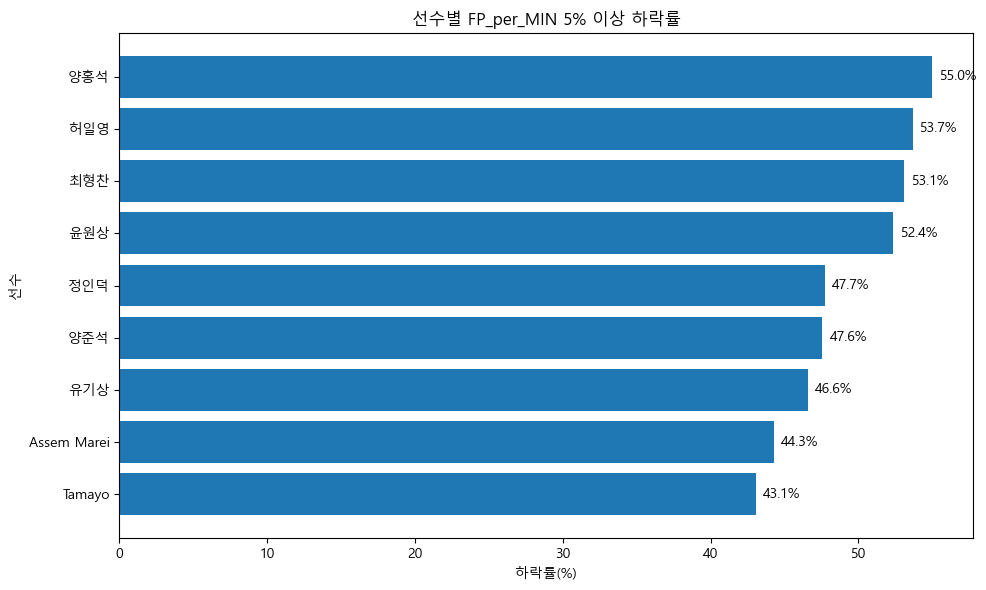

In [11]:
plot_df = player_summary.sort_values("drop_rate", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(plot_df["Player"], plot_df["drop_rate"] * 100)
plt.title("선수별 FP_per_MIN 5% 이상 하락률")
plt.xlabel("하락률(%)")
plt.ylabel("선수")

for i, v in enumerate(plot_df["drop_rate"] * 100):
    plt.text(v + 0.5, i, f"{v:.1f}%", va="center")

plt.tight_layout()
plt.show()

In [12]:
#시즌별 하락률 분석
season_summary = (
    df.groupby("season")
    .agg(
        games=("season", "count"),
        drop_rate=(target_col, "mean"),
        avg_current_FP_per_MIN=("current_FP_per_MIN", "mean"),
        avg_recent5_MIN_sum=("recent5_MIN_sum", "mean")
    )
    .reset_index()
)

display(season_summary)

,season,games,drop_rate,avg_current_FP_per_MIN,avg_recent5_MIN_sum
0,24-25,226,0.464602,0.809522,131.202257
1,25-26,286,0.489510,0.785682,124.838077


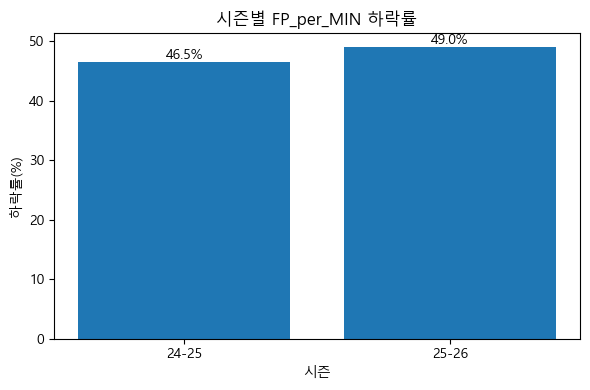

In [13]:
plt.figure(figsize=(6, 4))

plt.bar(season_summary["season"], season_summary["drop_rate"] * 100)
plt.title("시즌별 FP_per_MIN 하락률")
plt.xlabel("시즌")
plt.ylabel("하락률(%)")

for i, v in enumerate(season_summary["drop_rate"] * 100):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

In [14]:
#홈/원정별 하락률 분석
home_summary = (
    df.groupby("home")
    .agg(
        games=("home", "count"),
        drop_rate=(target_col, "mean"),
        avg_current_FP_per_MIN=("current_FP_per_MIN", "mean"),
        avg_recent5_MIN_sum=("recent5_MIN_sum", "mean")
    )
    .reset_index()
)

home_summary["home_label"] = home_summary["home"].map({1: "홈", 0: "원정"})

display(home_summary)

,home,games,drop_rate,avg_current_FP_per_MIN,avg_recent5_MIN_sum,home_label
0,0,274,0.492701,0.797292,128.491642,원정
1,1,238,0.462185,0.794954,126.675168,홈


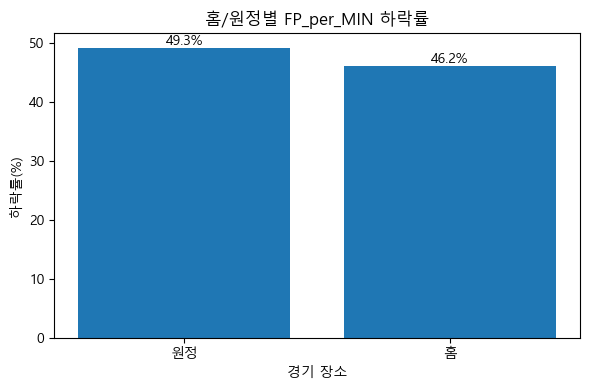

In [15]:
plt.figure(figsize=(6, 4))

plt.bar(home_summary["home_label"], home_summary["drop_rate"] * 100)
plt.title("홈/원정별 FP_per_MIN 하락률")
plt.xlabel("경기 장소")
plt.ylabel("하락률(%)")

for i, v in enumerate(home_summary["drop_rate"] * 100):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

In [16]:
#선발/벤치별 하락률 분석
starter_summary = (
    df.groupby("starter_flag")
    .agg(
        games=("starter_flag", "count"),
        drop_rate=(target_col, "mean"),
        avg_current_FP_per_MIN=("current_FP_per_MIN", "mean"),
        avg_recent5_MIN_sum=("recent5_MIN_sum", "mean"),
        avg_current_MIN=("current_MIN", "mean")
    )
    .reset_index()
)

starter_summary["starter_label"] = starter_summary["starter_flag"].map({
    1: "선발",
    0: "벤치"
})

display(starter_summary)

,starter_flag,games,drop_rate,avg_current_FP_per_MIN,avg_recent5_MIN_sum,avg_current_MIN,starter_label
0,0,135,0.614815,0.614237,101.513407,14.172000,벤치
1,1,377,0.429708,0.861366,137.005544,29.267029,선발


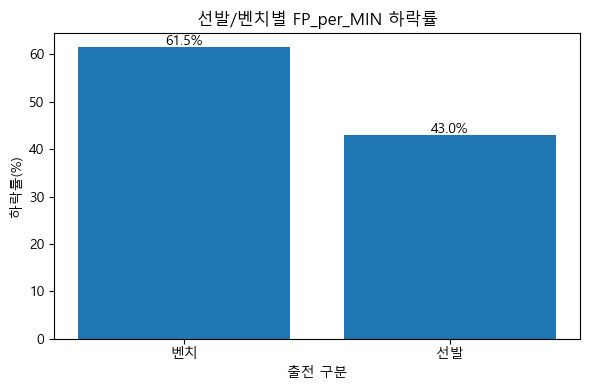

In [17]:
plt.figure(figsize=(6, 4))

plt.bar(starter_summary["starter_label"], starter_summary["drop_rate"] * 100)
plt.title("선발/벤치별 FP_per_MIN 하락률")
plt.xlabel("출전 구분")
plt.ylabel("하락률(%)")

for i, v in enumerate(starter_summary["drop_rate"] * 100):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

In [18]:
#포지션별 하락률 분석
pos_summary = (
    df.groupby("Pos")
    .agg(
        games=("Pos", "count"),
        drop_rate=(target_col, "mean"),
        avg_current_FP_per_MIN=("current_FP_per_MIN", "mean"),
        avg_recent5_MIN_sum=("recent5_MIN_sum", "mean")
    )
    .reset_index()
    .sort_values("drop_rate", ascending=False)
)

display(pos_summary)

,Pos,games,drop_rate,avg_current_FP_per_MIN,avg_recent5_MIN_sum
3,SF,129,0.534884,0.504202,119.820620
2,PG,131,0.503817,0.713389,122.564122
1,PF,98,0.469388,0.913214,127.323673
0,C,81,0.432099,1.396531,136.810617
4,SG,73,0.397260,0.637630,140.866575


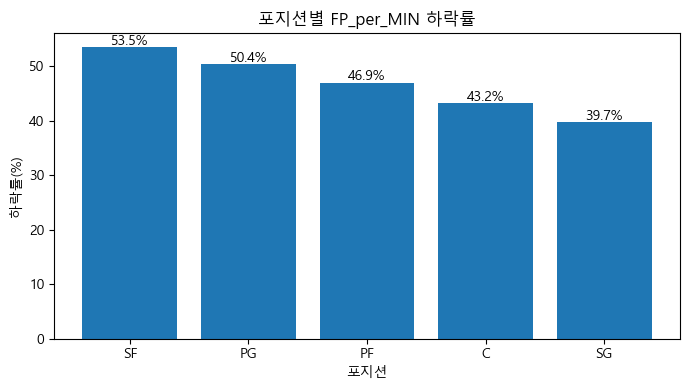

In [19]:
plt.figure(figsize=(7, 4))

plt.bar(pos_summary["Pos"], pos_summary["drop_rate"] * 100)
plt.title("포지션별 FP_per_MIN 하락률")
plt.xlabel("포지션")
plt.ylabel("하락률(%)")

for i, v in enumerate(pos_summary["drop_rate"] * 100):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

In [20]:
#상대팀별 하락률 분석
opponent_summary = (
    df.groupby("Opponent")
    .agg(
        games=("Opponent", "count"),
        drop_rate=(target_col, "mean"),
        avg_current_FP_per_MIN=("current_FP_per_MIN", "mean"),
        avg_recent5_MIN_sum=("recent5_MIN_sum", "mean")
    )
    .reset_index()
    .sort_values("drop_rate", ascending=False)
)

display(opponent_summary)

,Opponent,games,drop_rate,avg_current_FP_per_MIN,avg_recent5_MIN_sum
4,Seoul SK,55,0.654545,0.744309,123.826182
0,Anyang KGC,59,0.593220,0.792525,129.565254
7,Ulsan Mobis Phoebus,49,0.551020,0.696776,129.153878
3,Korea Gas Corporation,53,0.490566,0.792792,129.015849
8,Wonju Dongbu Promy,60,0.466667,0.820650,127.772500
1,Goyang Sono Skygunners,49,0.448980,0.758245,124.030612
6,Suwon KT Sonicboom,66,0.439394,0.766788,130.573636
2,Jeonju KCC Egis,58,0.379310,0.891172,128.199483
5,Seoul Samsung Thunders,63,0.317460,0.874794,125.983333


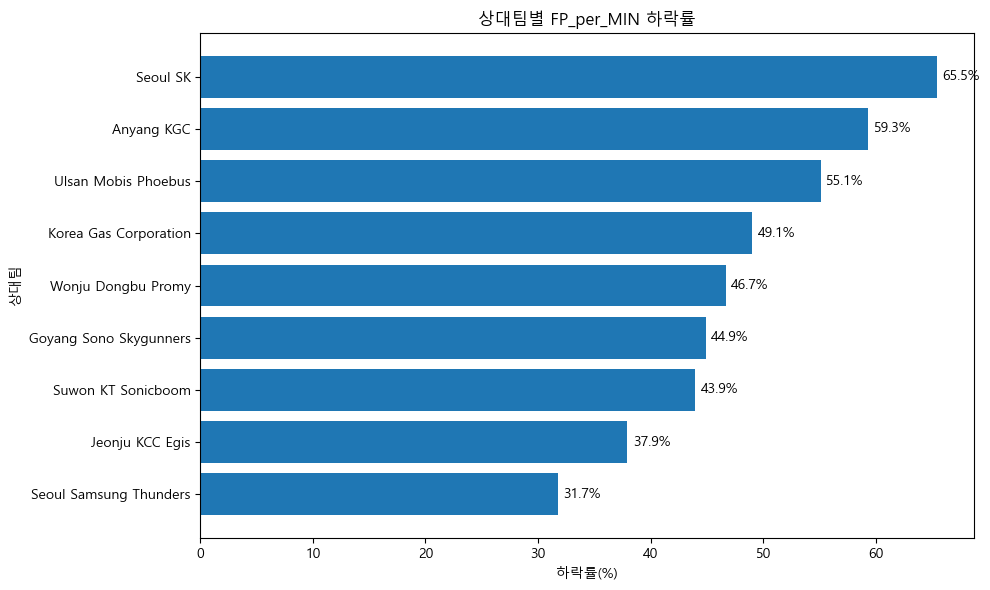

In [21]:
plot_df = opponent_summary.sort_values("drop_rate", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(plot_df["Opponent"], plot_df["drop_rate"] * 100)
plt.title("상대팀별 FP_per_MIN 하락률")
plt.xlabel("하락률(%)")
plt.ylabel("상대팀")

for i, v in enumerate(plot_df["drop_rate"] * 100):
    plt.text(v + 0.5, i, f"{v:.1f}%", va="center")

plt.tight_layout()
plt.show()

In [22]:
#피로도 분석 1: 최근 5경기 누적 출전시간 구간별 하락률
df["recent5_MIN_sum_bin"] = pd.qcut(
    df["recent5_MIN_sum"],
    q=4,
    labels=["낮음", "보통", "높음", "매우 높음"],
    duplicates="drop"
)

fatigue_summary = (
    df.groupby("recent5_MIN_sum_bin")
    .agg(
        games=("recent5_MIN_sum_bin", "count"),
        avg_recent5_MIN_sum=("recent5_MIN_sum", "mean"),
        drop_rate=(target_col, "mean")
    )
    .reset_index()
)

display(fatigue_summary)

,recent5_MIN_sum_bin,games,avg_recent5_MIN_sum,drop_rate
0,낮음,128,83.620234,0.500000
1,보통,128,124.365469,0.523438
2,높음,128,142.922578,0.398438
3,매우 높음,128,159.680781,0.492188


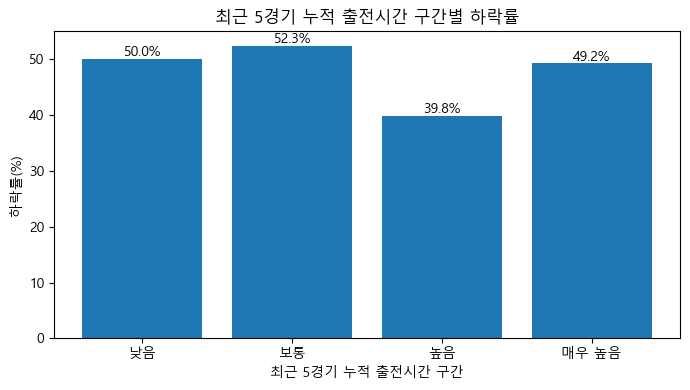

In [23]:
plt.figure(figsize=(7, 4))

plt.bar(
    fatigue_summary["recent5_MIN_sum_bin"].astype(str),
    fatigue_summary["drop_rate"] * 100
)

plt.title("최근 5경기 누적 출전시간 구간별 하락률")
plt.xlabel("최근 5경기 누적 출전시간 구간")
plt.ylabel("하락률(%)")

for i, v in enumerate(fatigue_summary["drop_rate"] * 100):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

In [24]:
#피로도 분석 2: 최근 5경기 30분 이상 출전 횟수별 하락률
high_min_summary = (
    df.groupby("recent5_high_MIN_count")
    .agg(
        games=("recent5_high_MIN_count", "count"),
        avg_recent5_MIN_sum=("recent5_MIN_sum", "mean"),
        drop_rate=(target_col, "mean")
    )
    .reset_index()
)

display(high_min_summary)

,recent5_high_MIN_count,games,avg_recent5_MIN_sum,drop_rate
0,0,138,88.318623,0.514493
1,1,104,124.098462,0.480769
2,2,103,138.483981,0.446602
3,3,104,150.622019,0.432692
4,4,50,162.879400,0.520000
5,5,13,168.360000,0.538462


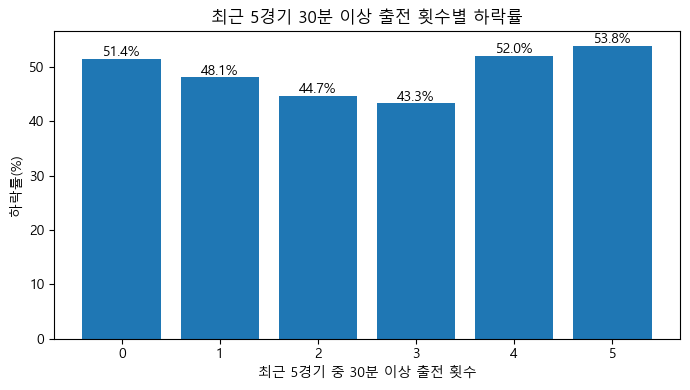

In [25]:
plt.figure(figsize=(7, 4))

plt.bar(
    high_min_summary["recent5_high_MIN_count"].astype(str),
    high_min_summary["drop_rate"] * 100
)

plt.title("최근 5경기 30분 이상 출전 횟수별 하락률")
plt.xlabel("최근 5경기 중 30분 이상 출전 횟수")
plt.ylabel("하락률(%)")

for i, v in enumerate(high_min_summary["drop_rate"] * 100):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

In [26]:
#피로도 분석 3: 휴식일별 하락률
rest_summary = (
    df.groupby("rest_days_fixed")
    .agg(
        games=("rest_days_fixed", "count"),
        drop_rate=(target_col, "mean"),
        avg_current_FP_per_MIN=("current_FP_per_MIN", "mean")
    )
    .reset_index()
)

display(rest_summary)

,rest_days_fixed,games,drop_rate,avg_current_FP_per_MIN
0,1,43,0.465116,0.834581
1,2,250,0.484000,0.808180
2,3,122,0.475410,0.783205
3,4,52,0.384615,0.812327
4,5,26,0.461538,0.713808
5,6,15,0.800000,0.669933
6,7,4,0.500000,0.831250


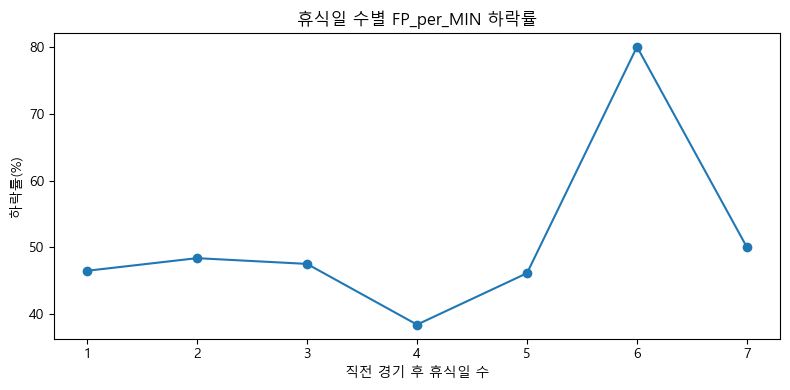

In [27]:
plt.figure(figsize=(8, 4))

plt.plot(
    rest_summary["rest_days_fixed"],
    rest_summary["drop_rate"] * 100,
    marker="o"
)

plt.title("휴식일 수별 FP_per_MIN 하락률")
plt.xlabel("직전 경기 후 휴식일 수")
plt.ylabel("하락률(%)")
plt.xticks(rest_summary["rest_days_fixed"])

plt.tight_layout()
plt.show()

In [28]:
#피로도 분석 4: 백투백 여부별 하락률
b2b_summary = (
    df.groupby("back_to_back")
    .agg(
        games=("back_to_back", "count"),
        drop_rate=(target_col, "mean"),
        avg_current_FP_per_MIN=("current_FP_per_MIN", "mean")
    )
    .reset_index()
)

b2b_summary["b2b_label"] = b2b_summary["back_to_back"].map({
    1: "백투백",
    0: "비백투백"
})

display(b2b_summary)

,back_to_back,games,drop_rate,avg_current_FP_per_MIN,b2b_label
0,0,469,0.479744,0.792687,비백투백
1,1,43,0.465116,0.834581,백투백


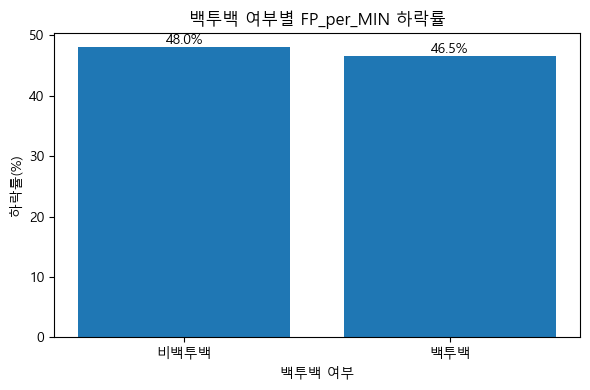

In [29]:
plt.figure(figsize=(6, 4))

plt.bar(b2b_summary["b2b_label"], b2b_summary["drop_rate"] * 100)

plt.title("백투백 여부별 FP_per_MIN 하락률")
plt.xlabel("백투백 여부")
plt.ylabel("하락률(%)")

for i, v in enumerate(b2b_summary["drop_rate"] * 100):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

In [32]:
#공격 부담 구간별 하락률
df["recent5_USG_Proxy_sum_bin"] = pd.qcut(
    df["recent5_USG_Proxy_sum"],
    q=4,
    labels=["낮음", "보통", "높음", "매우 높음"],
    duplicates="drop"
)

usg_summary = (
    df.groupby("recent5_USG_Proxy_sum_bin")
    .agg(
        games=("recent5_USG_Proxy_sum_bin", "count"),
        avg_recent5_USG_Proxy_sum=("recent5_USG_Proxy_sum", "mean"),
        drop_rate=(target_col, "mean")
    )
    .reset_index()
)

display(usg_summary)

,recent5_USG_Proxy_sum_bin,games,avg_recent5_USG_Proxy_sum,drop_rate
0,낮음,128,22.366875,0.507812
1,보통,128,40.292187,0.468750
2,높음,129,61.191318,0.441860
3,매우 높음,127,87.074961,0.496063


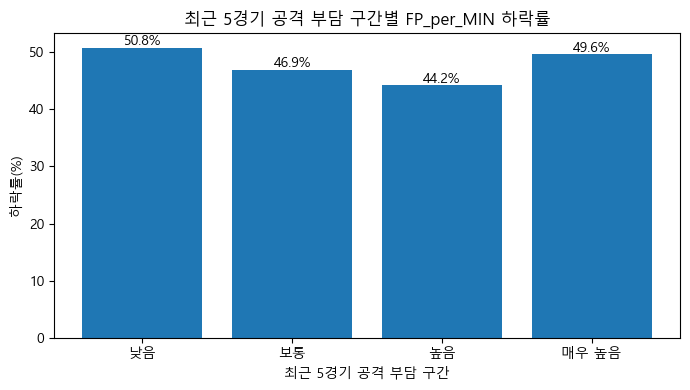

In [33]:
plt.figure(figsize=(7, 4))

plt.bar(
    usg_summary["recent5_USG_Proxy_sum_bin"].astype(str),
    usg_summary["drop_rate"] * 100
)

plt.title("최근 5경기 공격 부담 구간별 FP_per_MIN 하락률")
plt.xlabel("최근 5경기 공격 부담 구간")
plt.ylabel("하락률(%)")

for i, v in enumerate(usg_summary["drop_rate"] * 100):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

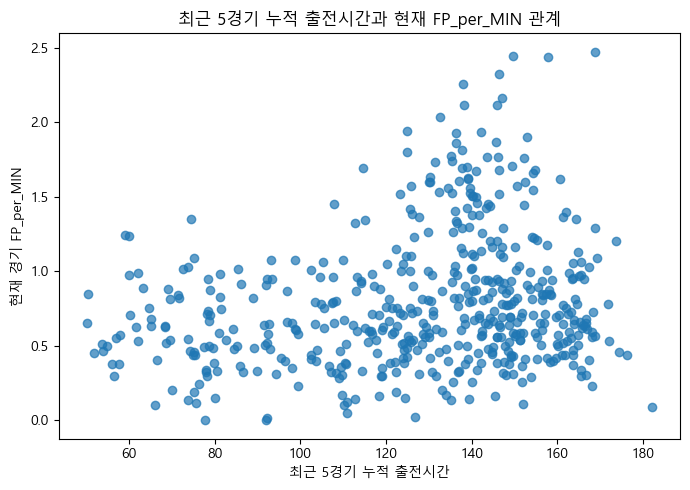

In [34]:
#산점도: 최근 5경기 누적 출전시간과 현재 FP_per_MIN
plt.figure(figsize=(7, 5))

plt.scatter(
    df["recent5_MIN_sum"],
    df["current_FP_per_MIN"],
    alpha=0.7
)

plt.title("최근 5경기 누적 출전시간과 현재 FP_per_MIN 관계")
plt.xlabel("최근 5경기 누적 출전시간")
plt.ylabel("현재 경기 FP_per_MIN")

plt.tight_layout()
plt.show()

In [35]:
numeric_cols = [
    "target_FP_per_MIN_drop_5",
    "recent3_weighted_FP_per_MIN",
    "recent3_TS_avg",
    "recent3_TOV_avg",
    "recent3_PTS_avg",
    "recent3_REB_avg",
    "recent3_AST_avg",
    "recent3_STL_avg",
    "recent3_BLK_avg",
    "recent3_MIN_avg",
    "recent5_MIN_sum",
    "recent5_high_MIN_count",
    "rest_days_fixed",
    "back_to_back",
    "recent3_USG_Proxy_per_MIN_avg",
    "recent5_USG_Proxy_sum",
    "home",
    "starter_flag"
]

corr_df = df[numeric_cols].corr()

print("Target과의 상관계수")
display(corr_df[target_col].sort_values(ascending=False))

Target과의 상관계수


target_FP_per_MIN_drop_5         1.000000
recent3_TS_avg                   0.149448
recent3_PTS_avg                  0.107596
recent3_weighted_FP_per_MIN      0.105262
recent3_STL_avg                  0.080676
recent3_BLK_avg                  0.047546
recent3_USG_Proxy_per_MIN_avg    0.038960
rest_days_fixed                  0.029103
recent3_REB_avg                  0.016589
recent3_AST_avg                  0.011486
recent5_USG_Proxy_sum           -0.005506
back_to_back                    -0.008122
recent3_MIN_avg                 -0.015905
recent5_MIN_sum                 -0.021452
recent5_high_MIN_count          -0.023159
home                            -0.030468
recent3_TOV_avg                 -0.038340
starter_flag                    -0.163275
Name: target_FP_per_MIN_drop_5, dtype: float64

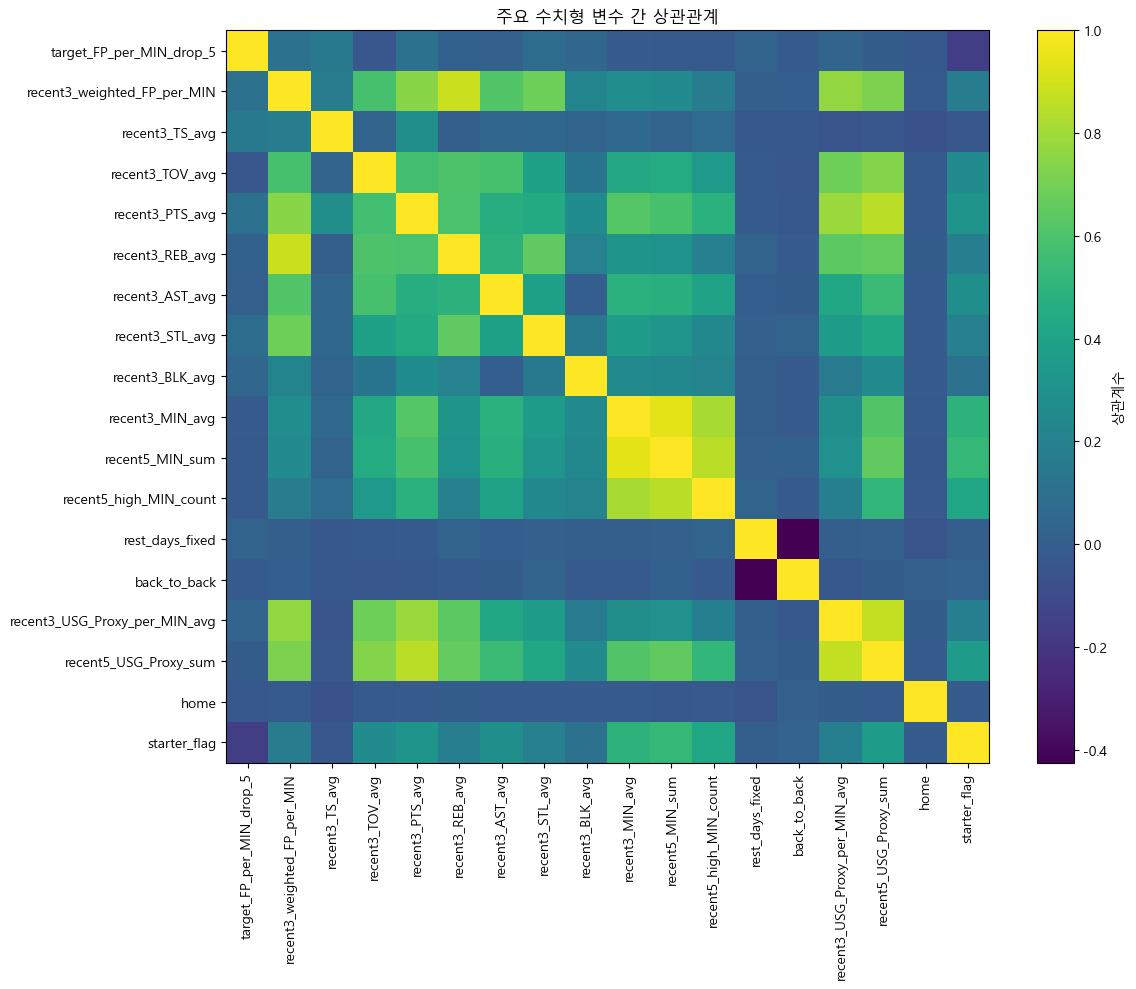

In [36]:
plt.figure(figsize=(12, 10))

plt.imshow(corr_df, aspect="auto")
plt.colorbar(label="상관계수")

plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.index)), corr_df.index)

plt.title("주요 수치형 변수 간 상관관계")

plt.tight_layout()
plt.show()

In [37]:
target_col = "target_FP_per_MIN_drop_5"

feature_cols = [
    # 최근 경기력
    "recent3_weighted_FP_per_MIN",
    "recent3_TS_avg",
    "recent3_TOV_avg",
    "recent3_PTS_avg",
    "recent3_REB_avg",
    "recent3_AST_avg",
    "recent3_STL_avg",
    "recent3_BLK_avg",

    # 피로도
    "recent3_MIN_avg",
    "recent5_MIN_sum",
    "recent5_high_MIN_count",
    "rest_days_fixed",
    "back_to_back",

    # 공격 부담
    "recent3_USG_Proxy_per_MIN_avg",
    "recent5_USG_Proxy_sum",

    # 경기 조건
    "home",
    "starter_flag",
    "Pos",
    "Opponent",
    "season"
]

X = df[feature_cols].copy()
y = df[target_col].copy()

display(X.head())

,recent3_weighted_FP_per_MIN,recent3_TS_avg,recent3_TOV_avg,recent3_PTS_avg,recent3_REB_avg,recent3_AST_avg,recent3_STL_avg,recent3_BLK_avg,recent3_MIN_avg,recent5_MIN_sum,recent5_high_MIN_count,rest_days_fixed,back_to_back,recent3_USG_Proxy_per_MIN_avg,recent5_USG_Proxy_sum,home,starter_flag,Pos,Opponent,season
0,1.300,0.519,2.667,15.000,10.000,4.667,1.000,0.333,27.183,143.60,2,2,0,0.631,88.12,1,1,C,Wonju Dongbu Promy,24-25
1,1.538,0.602,2.667,16.333,14.000,5.333,1.000,0.667,28.260,146.38,3,2,0,0.592,80.44,0,1,C,Korea Gas Corporation,24-25
2,1.658,0.619,1.333,16.667,13.667,6.000,1.000,0.667,27.577,142.48,2,4,0,0.556,80.96,0,1,C,Anyang KGC,24-25
3,1.588,0.714,1.333,16.000,14.333,6.333,0.667,0.667,28.570,139.24,2,2,0,0.443,74.08,0,1,C,Jeonju KCC Egis,24-25
4,1.527,0.622,1.333,14.333,11.667,5.000,1.667,0.333,26.527,132.63,1,2,0,0.499,68.64,1,1,C,Seoul Samsung Thunders,24-25


In [38]:
numeric_features = [
    "recent3_weighted_FP_per_MIN",
    "recent3_TS_avg",
    "recent3_TOV_avg",
    "recent3_PTS_avg",
    "recent3_REB_avg",
    "recent3_AST_avg",
    "recent3_STL_avg",
    "recent3_BLK_avg",
    "recent3_MIN_avg",
    "recent5_MIN_sum",
    "recent5_high_MIN_count",
    "rest_days_fixed",
    "back_to_back",
    "recent3_USG_Proxy_per_MIN_avg",
    "recent5_USG_Proxy_sum",
    "home",
    "starter_flag"
]

categorical_features = [
    "Pos",
    "Opponent",
    "season"
]

In [41]:
#train/test split
print("시즌별 데이터 수")
print(df["season"].value_counts())

if set(["24-25", "25-26"]).issubset(set(df["season"].astype(str).unique())):
    train_mask = df["season"].astype(str) == "24-25"
    test_mask = df["season"].astype(str) == "25-26"

    X_train = X[train_mask].copy()
    X_test = X[test_mask].copy()

    y_train = y[train_mask].copy()
    y_test = y[test_mask].copy()

    print("\n시즌 기준 분할 사용")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print("랜덤 분할 사용")

print("Train 크기:", X_train.shape)
print("Test 크기:", X_test.shape)

print("\nTrain target 비율")
print(y_train.value_counts(normalize=True))

print("\nTest target 비율")
print(y_test.value_counts(normalize=True))

시즌별 데이터 수
season
25-26    286
24-25    226
Name: count, dtype: int64

시즌 기준 분할 사용
Train 크기: (226, 20)
Test 크기: (286, 20)

Train target 비율
target_FP_per_MIN_drop_5
0    0.535398
1    0.464602
Name: proportion, dtype: float64

Test target 비율
target_FP_per_MIN_drop_5
0    0.51049
1    0.48951
Name: proportion, dtype: float64


In [42]:
#전처리
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [43]:
#logistic regression
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

y_pred_log = logistic_model.predict(X_test)
y_proba_log = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression 성능")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

print("\nClassification Report")
print(classification_report(y_test, y_pred_log))

Logistic Regression 성능
Accuracy: 0.6153846153846154
Precision: 0.6339285714285714
Recall: 0.5071428571428571
F1-score: 0.5634920634920635
ROC-AUC: 0.6643835616438356

Classification Report
              precision    recall  f1-score   support

           0       0.60      0.72      0.66       146
           1       0.63      0.51      0.56       140

    accuracy                           0.62       286
   macro avg       0.62      0.61      0.61       286
weighted avg       0.62      0.62      0.61       286



In [44]:
#random forest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest 성능")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest 성능
Accuracy: 0.6363636363636364
Precision: 0.6764705882352942
Recall: 0.4928571428571429
F1-score: 0.5702479338842975
ROC-AUC: 0.6996086105675148

Classification Report
              precision    recall  f1-score   support

           0       0.61      0.77      0.68       146
           1       0.68      0.49      0.57       140

    accuracy                           0.64       286
   macro avg       0.65      0.63      0.63       286
weighted avg       0.64      0.64      0.63       286



In [45]:
#gradient boosting
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42,
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3
    ))
])

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting 성능")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1-score:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_gb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting 성능
Accuracy: 0.5734265734265734
Precision: 0.575
Recall: 0.4928571428571429
F1-score: 0.5307692307692308
ROC-AUC: 0.6259784735812133

Classification Report
              precision    recall  f1-score   support

           0       0.57      0.65      0.61       146
           1       0.57      0.49      0.53       140

    accuracy                           0.57       286
   macro avg       0.57      0.57      0.57       286
weighted avg       0.57      0.57      0.57       286



In [46]:
model_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_log),
        "Precision": precision_score(y_test, y_pred_log),
        "Recall": recall_score(y_test, y_pred_log),
        "F1-score": f1_score(y_test, y_pred_log),
        "ROC-AUC": roc_auc_score(y_test, y_proba_log)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1-score": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_proba_rf)
    },
    {
        "Model": "Gradient Boosting",
        "Accuracy": accuracy_score(y_test, y_pred_gb),
        "Precision": precision_score(y_test, y_pred_gb),
        "Recall": recall_score(y_test, y_pred_gb),
        "F1-score": f1_score(y_test, y_pred_gb),
        "ROC-AUC": roc_auc_score(y_test, y_proba_gb)
    }
])

display(model_results)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.615385,0.633929,0.507143,0.563492,0.664384
1,Random Forest,0.636364,0.676471,0.492857,0.570248,0.699609
2,Gradient Boosting,0.573427,0.575000,0.492857,0.530769,0.625978


In [64]:
# Random Forest threshold 조정 실험

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds:
    y_pred_rf_threshold = (y_proba_rf >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_rf_threshold),
        "Precision": precision_score(y_test, y_pred_rf_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_rf_threshold),
        "F1-score": f1_score(y_test, y_pred_rf_threshold),
        "ROC-AUC": roc_auc_score(y_test, y_proba_rf)
    })

threshold_results_df = pd.DataFrame(threshold_results)

display(threshold_results_df)

,threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.30,0.513986,0.501805,0.992857,0.666667,0.699609
1,0.35,0.555944,0.525292,0.964286,0.680101,0.699609
2,0.40,0.594406,0.551724,0.914286,0.688172,0.699609
3,0.45,0.657343,0.617978,0.785714,0.691824,0.699609
4,0.50,0.636364,0.676471,0.492857,0.570248,0.699609
5,0.55,0.559441,0.659091,0.207143,0.315217,0.699609
6,0.60,0.534965,1.000000,0.050000,0.095238,0.699609


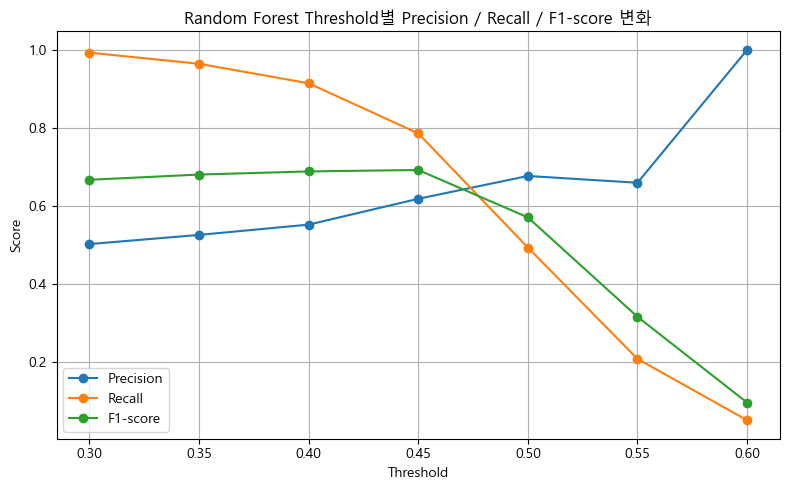

In [70]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["F1-score"],
    marker="o",
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Random Forest Threshold별 Precision / Recall / F1-score 변화")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [71]:
# F1-score가 가장 높은 threshold 자동 선택
best_threshold = threshold_results_df.loc[
    threshold_results_df["F1-score"].idxmax(),
    "threshold"
]

print(f"선택된 best_threshold: {best_threshold}")

선택된 best_threshold: 0.45


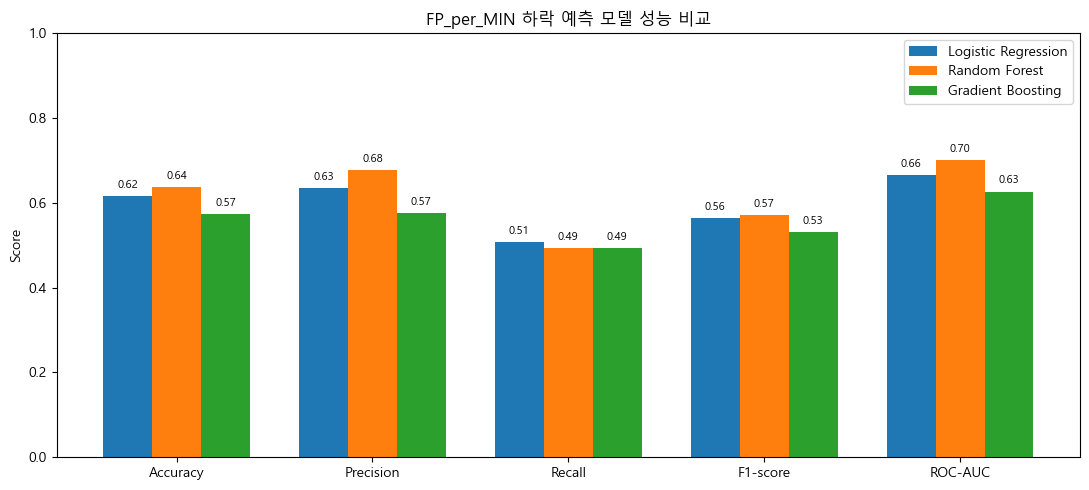

In [74]:
#기존모델 성능
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(11, 5))

plt.bar(x - width, model_results.loc[0, metrics], width, label="Logistic Regression")
plt.bar(x, model_results.loc[1, metrics], width, label="Random Forest")
plt.bar(x + width, model_results.loc[2, metrics], width, label="Gradient Boosting")

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("FP_per_MIN 하락 예측 모델 성능 비교")
plt.legend()

for model_idx in range(len(model_results)):
    for i, metric in enumerate(metrics):
        offset = (model_idx - 1) * width
        plt.text(
            i + offset,
            model_results.loc[model_idx, metric] + 0.02,
            f"{model_results.loc[model_idx, metric]:.2f}",
            ha="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

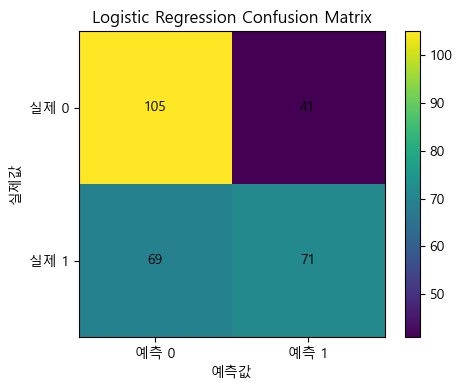

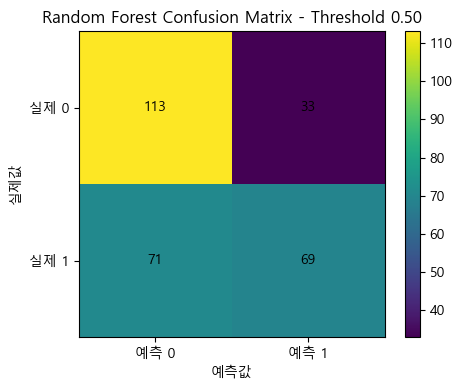

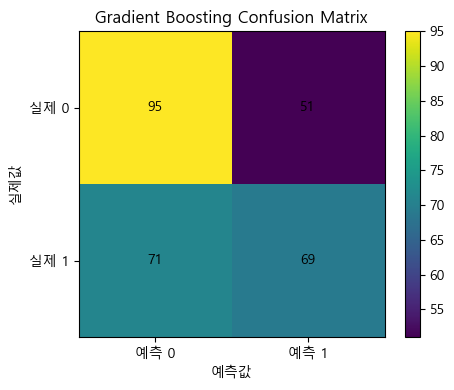

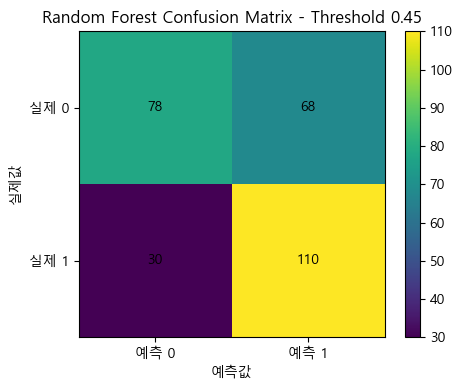

In [75]:
# confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.colorbar()

    plt.xticks([0, 1], ["예측 0", "예측 1"])
    plt.yticks([0, 1], ["실제 0", "실제 1"])

    plt.title(title)
    plt.xlabel("예측값")
    plt.ylabel("실제값")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()


# 기존 모델들
plot_confusion_matrix(y_test, y_pred_log, "Logistic Regression Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix - Threshold 0.50")
plot_confusion_matrix(y_test, y_pred_gb, "Gradient Boosting Confusion Matrix")

# threshold 조정 Random Forest
y_pred_rf_best_threshold = (y_proba_rf >= best_threshold).astype(int)
plot_confusion_matrix(
    y_test,
    y_pred_rf_best_threshold,
    f"Random Forest Confusion Matrix - Threshold {best_threshold}"
)

In [76]:
print(f"Random Forest 성능 - Threshold {best_threshold}")

print("Accuracy:", accuracy_score(y_test, y_pred_rf_best_threshold))
print("Precision:", precision_score(y_test, y_pred_rf_best_threshold, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf_best_threshold))
print("F1-score:", f1_score(y_test, y_pred_rf_best_threshold))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf_best_threshold))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf_best_threshold))

Random Forest 성능 - Threshold 0.45
Accuracy: 0.6573426573426573
Precision: 0.6179775280898876
Recall: 0.7857142857142857
F1-score: 0.6918238993710691
ROC-AUC: 0.6996086105675148

Confusion Matrix
[[ 78  68]
 [ 30 110]]

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.53      0.61       146
           1       0.62      0.79      0.69       140

    accuracy                           0.66       286
   macro avg       0.67      0.66      0.65       286
weighted avg       0.67      0.66      0.65       286



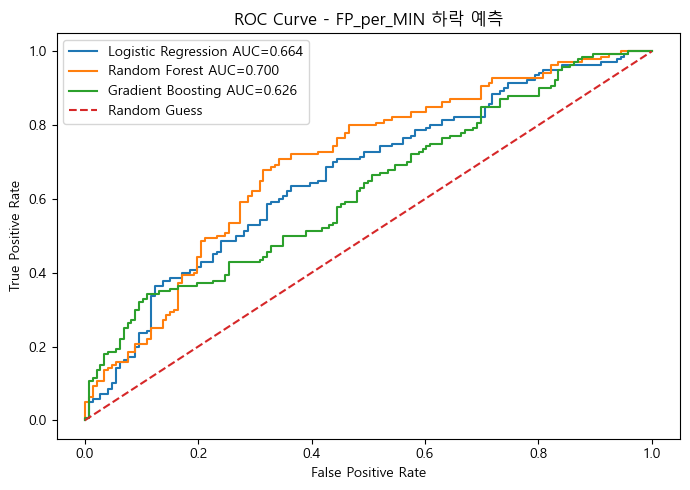

In [77]:
# ROC curve
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)

auc_log = roc_auc_score(y_test, y_proba_log)
auc_rf = roc_auc_score(y_test, y_proba_rf)
auc_gb = roc_auc_score(y_test, y_proba_gb)

plt.figure(figsize=(7, 5))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression AUC={auc_log:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC={auc_rf:.3f}")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting AUC={auc_gb:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.title("ROC Curve - FP_per_MIN 하락 예측")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

In [78]:
# Random Forest 변수 중요도
preprocessor_fitted = rf_model.named_steps["preprocessor"]

num_feature_names = numeric_features

cat_feature_names = (
    preprocessor_fitted
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
    .tolist()
)

all_feature_names = num_feature_names + cat_feature_names

importances = rf_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(feature_importance_df.head(20))

,feature,importance
0,recent3_weighted_FP_per_MIN,0.115026
4,recent3_REB_avg,0.096774
13,recent3_USG_Proxy_per_MIN_avg,0.081053
1,recent3_TS_avg,0.074910
3,recent3_PTS_avg,0.065722
9,recent5_MIN_sum,0.063424
8,recent3_MIN_avg,0.061043
14,recent5_USG_Proxy_sum,0.059731
6,recent3_STL_avg,0.056808
5,recent3_AST_avg,0.050799


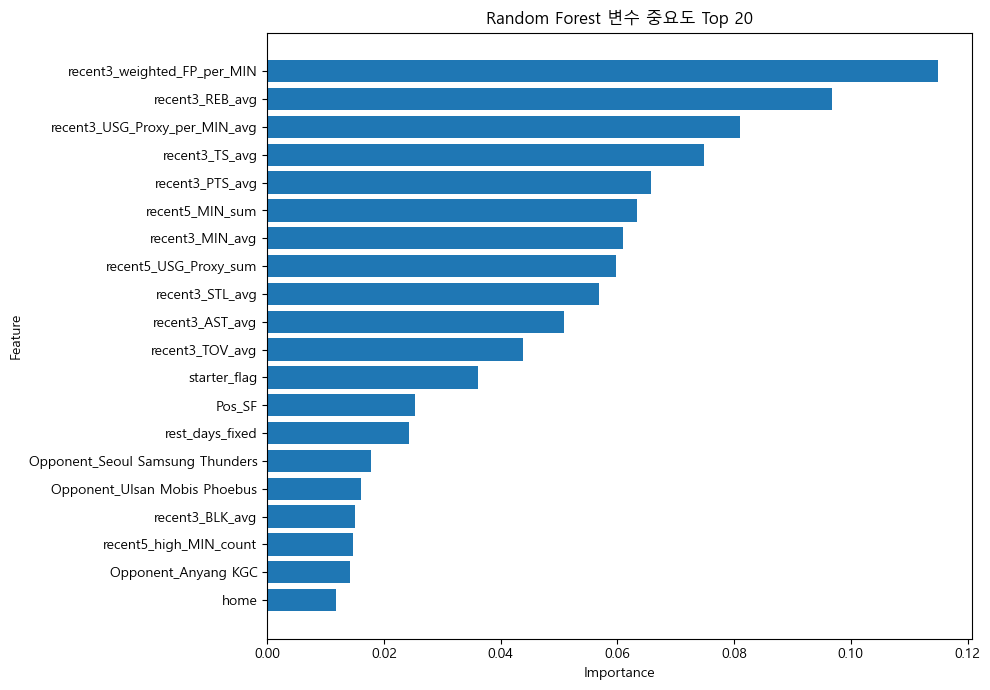

In [79]:
top_n = 20
top_features = feature_importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(top_features["feature"], top_features["importance"])

plt.title("Random Forest 변수 중요도 Top 20")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [80]:
# Logistic Regression 계수 확인
log_preprocessor_fitted = logistic_model.named_steps["preprocessor"]

num_feature_names = numeric_features

cat_feature_names = (
    log_preprocessor_fitted
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
    .tolist()
)

all_feature_names = num_feature_names + cat_feature_names

coef = logistic_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coef
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

display(coef_df.head(20))

,feature,coefficient,abs_coefficient
17,Pos_C,-1.393457,1.393457
20,Pos_SF,1.153250,1.153250
27,Opponent_Seoul Samsung Thunders,-0.892888,0.892888
29,Opponent_Ulsan Mobis Phoebus,0.761931,0.761931
0,recent3_weighted_FP_per_MIN,0.745727,0.745727
22,Opponent_Anyang KGC,0.611260,0.611260
19,Pos_PG,0.597020,0.597020
26,Opponent_Seoul SK,0.463842,0.463842
24,Opponent_Jeonju KCC Egis,-0.403309,0.403309
18,Pos_PF,-0.399015,0.399015


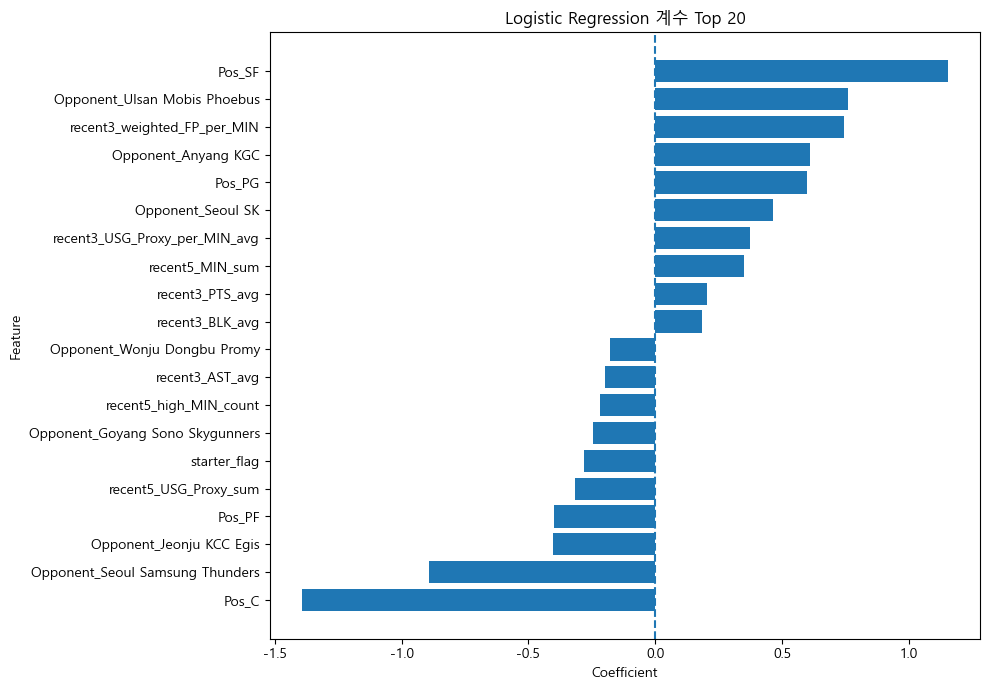

In [81]:
top_coef = coef_df.head(20).sort_values("coefficient", ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.axvline(0, linestyle="--")

plt.title("Logistic Regression 계수 Top 20")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [82]:
test_result = df.loc[X_test.index].copy()

test_result["pred_drop_log"] = y_pred_log
test_result["pred_drop_prob_log"] = y_proba_log

test_result["pred_drop_rf"] = y_pred_rf
test_result["pred_drop_prob_rf"] = y_proba_rf

test_result["pred_drop_gb"] = y_pred_gb
test_result["pred_drop_prob_gb"] = y_proba_gb

# threshold 조정 Random Forest 예측 결과
test_result["pred_drop_rf_threshold"] = y_pred_rf_best_threshold
test_result["best_threshold"] = best_threshold

display(test_result[[
    "Player",
    "season",
    "Date_fixed",
    "Opponent",
    "home",
    "starter_flag",
    "current_FP_per_MIN",
    "recent3_weighted_FP_per_MIN",
    "target_FP_per_MIN_drop_5",
    "pred_drop_rf",
    "pred_drop_rf_threshold",
    "pred_drop_prob_rf"
]].head())

,Player,season,Date_fixed,Opponent,home,starter_flag,current_FP_per_MIN,recent3_weighted_FP_per_MIN,target_FP_per_MIN_drop_5,pred_drop_rf,pred_drop_rf_threshold,pred_drop_prob_rf
28,Assem Marei,25-26,2025-10-20,Korea Gas Corporation,1,1,1.596,1.757,1,0,0,0.426057
29,Assem Marei,25-26,2025-10-25,Ulsan Mobis Phoebus,0,1,1.761,1.643,0,0,0,0.448405
30,Assem Marei,25-26,2025-10-27,Jeonju KCC Egis,1,1,1.575,1.840,1,1,1,0.532171
31,Assem Marei,25-26,2025-11-01,Goyang Sono Skygunners,0,0,0.647,1.654,1,1,1,0.572819
32,Assem Marei,25-26,2025-11-02,Seoul SK,0,1,1.387,1.482,1,0,0,0.404420


In [83]:
# 선수별 예측 하락 위험도
player_risk_summary = (
    test_result.groupby("Player")
    .agg(
        games=("Player", "count"),
        actual_drop_rate=("target_FP_per_MIN_drop_5", "mean"),
        avg_pred_drop_prob_rf=("pred_drop_prob_rf", "mean"),
        pred_drop_rate_threshold=("pred_drop_rf_threshold", "mean"),
        avg_recent5_MIN_sum=("recent5_MIN_sum", "mean"),
        avg_recent5_high_MIN_count=("recent5_high_MIN_count", "mean"),
        avg_rest_days=("rest_days_fixed", "mean")
    )
    .reset_index()
    .sort_values("avg_pred_drop_prob_rf", ascending=False)
)

display(player_risk_summary)

,Player,games,actual_drop_rate,avg_pred_drop_prob_rf,pred_drop_rate_threshold,avg_recent5_MIN_sum,avg_recent5_high_MIN_count,avg_rest_days
3,양홍석,20,0.550000,0.500962,0.900000,112.278000,0.450000,2.400000
5,윤원상,21,0.523810,0.494159,0.714286,78.353333,0.238095,2.476190
2,양준석,37,0.486486,0.487753,0.756757,145.643784,2.756757,2.621622
0,Assem Marei,42,0.452381,0.487570,0.690476,144.119048,2.238095,2.761905
8,허일영,18,0.555556,0.477033,0.722222,85.038333,0.277778,2.666667
1,Tamayo,33,0.424242,0.470238,0.666667,144.735455,2.727273,2.696970
6,정인덕,43,0.465116,0.463219,0.581395,127.408372,1.581395,2.720930
7,최형찬,32,0.531250,0.428182,0.437500,78.621250,0.312500,2.562500
4,유기상,40,0.500000,0.419690,0.350000,151.737250,2.875000,2.775000


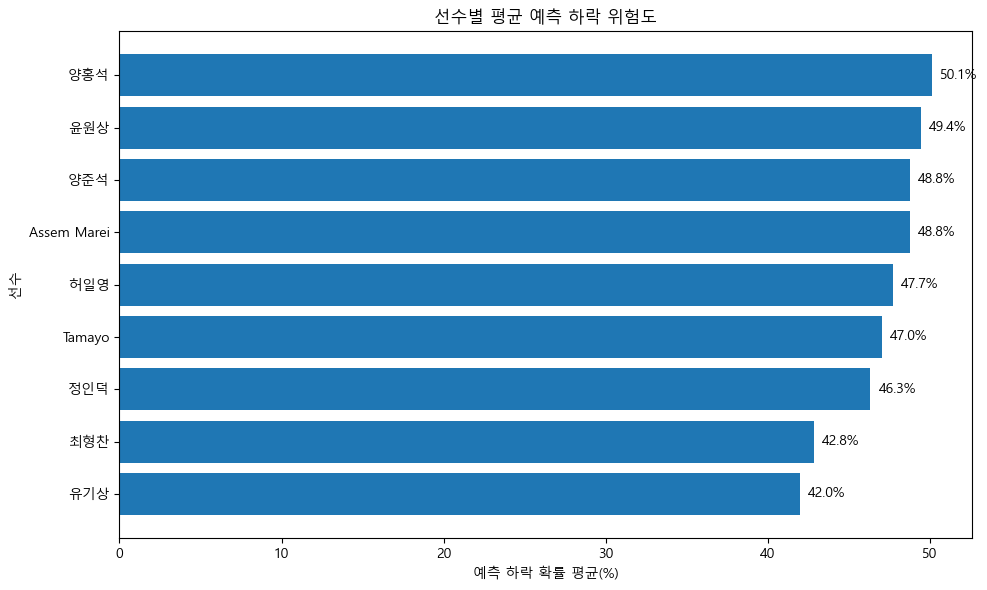

In [84]:
plot_df = player_risk_summary.sort_values("avg_pred_drop_prob_rf", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(plot_df["Player"], plot_df["avg_pred_drop_prob_rf"] * 100)

plt.title("선수별 평균 예측 하락 위험도")
plt.xlabel("예측 하락 확률 평균(%)")
plt.ylabel("선수")

for i, v in enumerate(plot_df["avg_pred_drop_prob_rf"] * 100):
    plt.text(v + 0.5, i, f"{v:.1f}%", va="center")

plt.tight_layout()
plt.show()

In [88]:
# 위험도 등급 생성
def risk_level(prob):
    if prob >= 0.55:
        return "높음"
    elif prob >= best_threshold:
        return "보통"
    else:
        return "낮음"

test_result["risk_level"] = test_result["pred_drop_prob_rf"].apply(risk_level)

display(test_result[[
    "Player",
    "Date_fixed",
    "Opponent",
    "recent5_MIN_sum",
    "recent5_high_MIN_count",
    "rest_days_fixed",
    "back_to_back",
    "pred_drop_prob_rf",
    "pred_drop_rf_threshold",
    "risk_level"
]].sort_values("pred_drop_prob_rf", ascending=False).head(20))

,Player,Date_fixed,Opponent,recent5_MIN_sum,recent5_high_MIN_count,rest_days_fixed,back_to_back,pred_drop_prob_rf,pred_drop_rf_threshold,risk_level
425,정인덕,2026-04-08,Ulsan Mobis Phoebus,109.65,1,3,0,0.683957,1,높음
413,정인덕,2026-02-08,Anyang KGC,135.09,2,3,0,0.665021,1,높음
409,정인덕,2026-01-28,Wonju Dongbu Promy,147.65,3,3,0,0.656632,1,높음
319,윤원상,2025-12-28,Anyang KGC,110.46,1,2,0,0.624259,1,높음
198,양준석,2025-12-13,Seoul SK,127.18,1,6,0,0.621066,1,높음
320,윤원상,2025-12-31,Ulsan Mobis Phoebus,110.78,1,3,0,0.611533,1,높음
316,유기상,2026-04-08,Ulsan Mobis Phoebus,165.36,4,3,0,0.604745,1,높음
506,허일영,2026-02-05,Seoul Samsung Thunders,104.75,1,2,0,0.599212,1,높음
62,Assem Marei,2026-03-08,Seoul SK,140.52,1,2,0,0.598632,1,높음
216,양준석,2026-03-08,Seoul SK,142.20,2,2,0,0.595838,1,높음


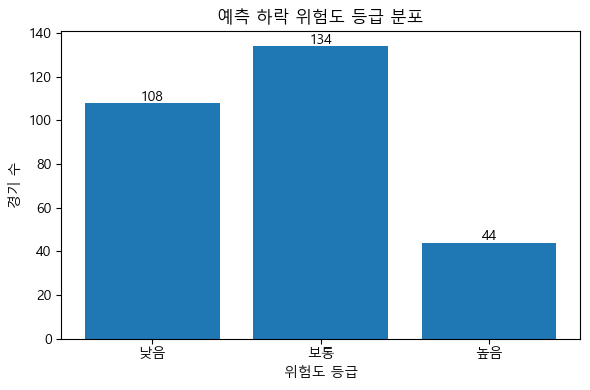

In [86]:
risk_counts = test_result["risk_level"].value_counts().reindex(["낮음", "보통", "높음"]).fillna(0)

plt.figure(figsize=(6, 4))

plt.bar(risk_counts.index, risk_counts.values)

plt.title("예측 하락 위험도 등급 분포")
plt.xlabel("위험도 등급")
plt.ylabel("경기 수")

for i, v in enumerate(risk_counts.values):
    plt.text(i, v + 1, str(int(v)), ha="center")

plt.tight_layout()
plt.show()

In [87]:
import os

os.makedirs("results", exist_ok=True)

raw_df.to_csv("results/raw_dataset.csv", index=False, encoding="utf-8-sig")
df.to_csv("results/feature_dataset.csv", index=False, encoding="utf-8-sig")

player_summary.to_csv("results/player_summary.csv", index=False, encoding="utf-8-sig")
season_summary.to_csv("results/season_summary.csv", index=False, encoding="utf-8-sig")
home_summary.to_csv("results/home_summary.csv", index=False, encoding="utf-8-sig")
starter_summary.to_csv("results/starter_summary.csv", index=False, encoding="utf-8-sig")
pos_summary.to_csv("results/pos_summary.csv", index=False, encoding="utf-8-sig")
opponent_summary.to_csv("results/opponent_summary.csv", index=False, encoding="utf-8-sig")

fatigue_summary.to_csv("results/fatigue_summary.csv", index=False, encoding="utf-8-sig")
high_min_summary.to_csv("results/high_min_summary.csv", index=False, encoding="utf-8-sig")
rest_summary.to_csv("results/rest_summary.csv", index=False, encoding="utf-8-sig")
b2b_summary.to_csv("results/b2b_summary.csv", index=False, encoding="utf-8-sig")
usg_summary.to_csv("results/usg_summary.csv", index=False, encoding="utf-8-sig")

model_results.to_csv("results/model_results.csv", index=False, encoding="utf-8-sig")
threshold_results_df.to_csv("results/threshold_comparison.csv", index=False, encoding="utf-8-sig")

feature_importance_df.to_csv("results/rf_feature_importance.csv", index=False, encoding="utf-8-sig")
coef_df.to_csv("results/logistic_coefficients.csv", index=False, encoding="utf-8-sig")

test_result.to_csv("results/test_predictions.csv", index=False, encoding="utf-8-sig")
player_risk_summary.to_csv("results/player_risk_summary.csv", index=False, encoding="utf-8-sig")

print("저장 완료: results 폴더에 CSV 파일들이 저장되었습니다.")
print(f"선택된 Random Forest threshold: {best_threshold}")

저장 완료: results 폴더에 CSV 파일들이 저장되었습니다.
선택된 Random Forest threshold: 0.45


In [90]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(rf_model, "models/random_forest_model.pkl")
joblib.dump(X_test, "models/X_test.pkl")
joblib.dump(y_test, "models/y_test.pkl")

print("모델 저장 완료")

모델 저장 완료
